# Data Prep

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import sys, os
sys.path.append(os.path.abspath(".."))
#print("Estoy aquí:", os.getcwd())
#print("Archivos en esta carpeta:", os.listdir())


In [2]:
from src.preprocess.preprocessor import get_df
from src.config_training import TrainSettings

settings = TrainSettings()

TRAIN_START_DATE = settings.TRAIN_START_DATE
TRAIN_END_DATE = settings.TRAIN_END_DATE
VAL_START_DATE = settings.VAL_START_DATE
VAL_END_DATE = settings.VAL_END_DATE

TEST23_START_DATE = settings.TEST23_START_DATE
TEST23_END_DATE = settings.TEST23_END_DATE
TEST24_START_DATE = settings.TEST24_START_DATE
TEST24_END_DATE = settings.TEST24_END_DATE

INDICATORS = settings.INDICATORS

df_train = get_df(TRAIN_START_DATE, TRAIN_END_DATE, "../src/preprocess/tickers/ticker_lists.json")
df_val = get_df(VAL_START_DATE, VAL_END_DATE, "../src/preprocess/tickers/ticker_lists.json")
df_test23 = get_df(TEST23_START_DATE, TEST23_END_DATE, "../src/preprocess/tickers/ticker_lists.json")
df_test24 = get_df(TEST24_START_DATE, TEST24_END_DATE, "../src/preprocess/tickers/ticker_lists.json")

stock_dimension = len(df_train.tic.unique())


From: 2017-12-02 00:00:00
To: 2022-01-01
Shape of DataFrame:  (30810, 8)
Successfully added technical indicators
From: 2021-12-02 00:00:00
To: 2023-01-01
Shape of DataFrame:  (8160, 8)
Successfully added technical indicators
From: 2022-12-02 00:00:00
To: 2024-01-01
Shape of DataFrame:  (8100, 8)
Successfully added technical indicators
From: 2023-12-02 00:00:00
To: 2025-01-01
Shape of DataFrame:  (8130, 8)
Successfully added technical indicators


# Base RL

## Hyperparameter optimization

In [3]:
from src.hyperparameter_searching.base_RL_hyperparam_op import hyperparams_opt_RL

hs_opt = hyperparams_opt_RL(
    df_train=df_train,
    df_test=df_val,
    indicators=INDICATORS,
    n_episodes_train=50,
    n_trials=50
)

hs_opt.run_opt()

ImportError: cannot import name 'hyperparams_opt_RL' from 'src.hyperparameter_searching.base_RL_hyperparam_op' (c:\Users\andoni.iribarren\Desktop\TFM\HRL_MAML_StockTrading\src\hyperparameter_searching\base_RL_hyperparam_op.py)

## Training

In [3]:
# TRAINING with BEST HPs
from src.env_stocktrading.trading_env_RL import StockTradingEnv
from src.agent.base_RL_models import baseRLAgent

# state_space_noHRL = [balance, close prices_i, stock_shares_i, MACD_i, rsi30_i, cci30_i]
episode_len = df_train.dayorder.nunique()
state_space = 1 + 2*stock_dimension + len(INDICATORS)*stock_dimension 

buy_cost_list = sell_cost_list = [0.001] * stock_dimension
num_stock_shares = [0] * stock_dimension

tr_env = StockTradingEnv(
    df = df_train,
    stock_dim=stock_dimension,
    hmax= 100,
    initial_amount=1000000,
    num_stock_shares=num_stock_shares,
    buy_cost_pct=buy_cost_list,
    sell_cost_pct=sell_cost_list,
    state_space= state_space,
    action_space= stock_dimension,
    tech_indicator_list=INDICATORS,
    make_plots=False,
    print_verbosity=1
)

agent = baseRLAgent(env=tr_env)

best_params = settings.best_hiperparams_RL

"""model = agent.get_model("a2c",
                        learning_rate = best_params['learning_rate'],
                        gamma = best_params['gamma'],
                        max_grad_norm = best_params['max_grad_norm'],
                        n_steps = 256,#best_params['n_steps'],
                        ent_coef = best_params['ent_coef'],
                        verbose=1)"""

model = agent.get_model("ppo",
                        verbose=0)

n_episodes = 400
trained_model = agent.train_model(
    model,
    tb_log_name="logs2312",
    total_timesteps= n_episodes*episode_len
)

day: 1007, episode: 1
begin_total_asset: 1000000.00
end_total_asset: 1393546.89
total_reward: 393546.89
total_cost: 92120.50
total_trades: 27557
Sharpe: 0.507
day: 1007, episode: 2
begin_total_asset: 1000000.00
end_total_asset: 1383307.64
total_reward: 383307.64
total_cost: 94822.93
total_trades: 27588
Sharpe: 0.485
day: 1007, episode: 3
begin_total_asset: 1000000.00
end_total_asset: 1435562.50
total_reward: 435562.50
total_cost: 93660.49
total_trades: 27622
Sharpe: 0.534
day: 1007, episode: 4
begin_total_asset: 1000000.00
end_total_asset: 1533838.29
total_reward: 533838.29
total_cost: 96192.77
total_trades: 27877
Sharpe: 0.602
day: 1007, episode: 5
begin_total_asset: 1000000.00
end_total_asset: 1472269.91
total_reward: 472269.91
total_cost: 96359.03
total_trades: 27675
Sharpe: 0.578
day: 1007, episode: 6
begin_total_asset: 1000000.00
end_total_asset: 1459687.37
total_reward: 459687.37
total_cost: 94087.87
total_trades: 27660
Sharpe: 0.548
day: 1007, episode: 7
begin_total_asset: 10000

## RL metrics

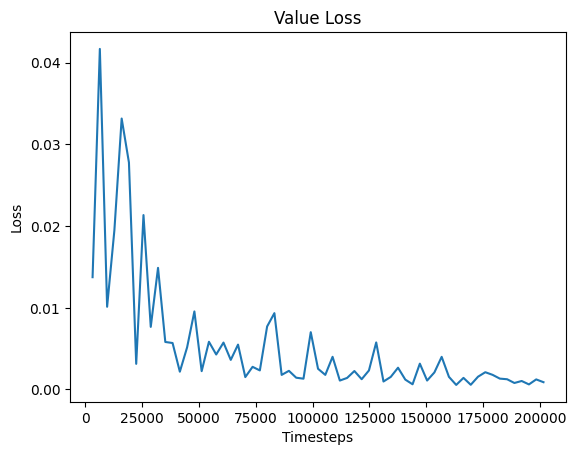

In [3]:
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

%matplotlib inline

ea = event_accumulator.EventAccumulator("logs/a2c_best_hp_1")  # cambia tu ruta
ea.Reload()

loss_key = "train/value_loss"
data = ea.Scalars(loss_key)

steps = [x.step for x in data]
values = [x.value for x in data]

plt.plot(steps, values)
plt.title("Value Loss")
plt.xlabel("Timesteps")
plt.ylabel("Loss")
plt.show()

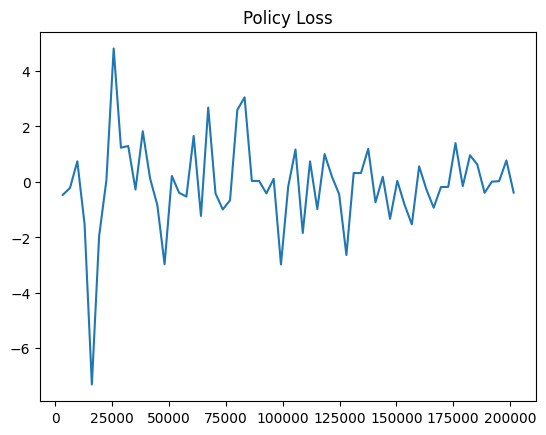

In [4]:
loss_key = "train/policy_loss"
data = ea.Scalars(loss_key)

plt.plot([x.step for x in data], [x.value for x in data])
plt.title("Policy Loss")
plt.show()

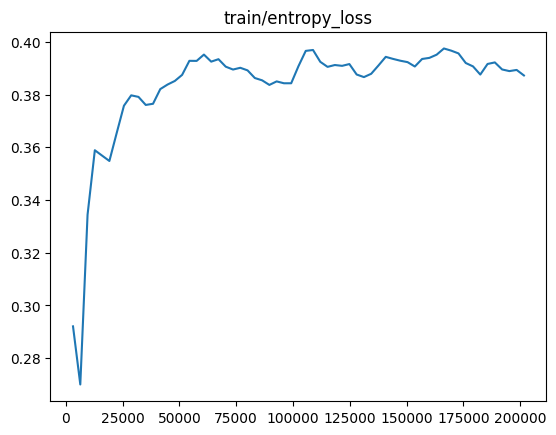

In [7]:
loss_key = "train/entropy_loss"
#loss_key = "rollout/ep_rew_mean"
#data = ea.Scalars(loss_key)

data=ea.Scalars("rollout/ep_rew_mean")

plt.plot([x.step for x in data], [x.value for x in data])
plt.title(loss_key)
plt.show()

[ScalarEvent(wall_time=1765926596.271882, step=3200, value=0.2920403480529785),
 ScalarEvent(wall_time=1765926604.353344, step=6400, value=0.26998817920684814),
 ScalarEvent(wall_time=1765926612.4808662, step=9600, value=0.33441999554634094),
 ScalarEvent(wall_time=1765926620.756518, step=12800, value=0.3588740825653076),
 ScalarEvent(wall_time=1765926628.7803988, step=16000, value=0.3568272590637207),
 ScalarEvent(wall_time=1765926636.966802, step=19200, value=0.3547993302345276),
 ScalarEvent(wall_time=1765926645.0466833, step=22400, value=0.3653540015220642),
 ScalarEvent(wall_time=1765926653.0806506, step=25600, value=0.37575414776802063),
 ScalarEvent(wall_time=1765926661.2562788, step=28800, value=0.379705011844635),
 ScalarEvent(wall_time=1765926669.4134576, step=32000, value=0.3791176676750183),
 ScalarEvent(wall_time=1765926677.4827266, step=35200, value=0.37605977058410645),
 ScalarEvent(wall_time=1765926685.789328, step=38400, value=0.3765031099319458),
 ScalarEvent(wall_tim

# VALIDATION

In [4]:
# VALIDATION
val_env = StockTradingEnv(
    df = df_val,
    stock_dim=stock_dimension,
    hmax= 100,
    initial_amount=1000000,
    num_stock_shares=num_stock_shares,
    buy_cost_pct=buy_cost_list,
    sell_cost_pct=sell_cost_list,
    state_space= state_space,
    action_space= stock_dimension,
    tech_indicator_list=INDICATORS,
    make_plots=True,
    print_verbosity=1
)

df_account_value_a2c, df_actions_a2c, last_state = agent.predict_RL(
    model=trained_model, 
    environment = val_env)


Starting prediction...
day: 250, episode: 2
begin_total_asset: 1000000.00
end_total_asset: 841989.40
total_reward: -158010.60
total_cost: 2618.33
total_trades: 4202
Sharpe: -0.640
hit end!


# TESTING

In [11]:
# AÑO 2023
test23_env = StockTradingEnv(
    df = df_test23,
    stock_dim=stock_dimension,
    hmax= 100,
    initial_amount=1000000,
    num_stock_shares=num_stock_shares,
    buy_cost_pct=buy_cost_list,
    sell_cost_pct=sell_cost_list,
    state_space= state_space,
    action_space= stock_dimension,
    tech_indicator_list=INDICATORS,
    make_plots=True,
    print_verbosity=1
)

df_account_test23_RL, df_actions_test23_RL, last_state_test23_RL = agent.predict_RL(
    model=trained_model, 
    environment = test23_env)

df_account_test23_RL.to_csv("results/dfs/cuenta_test23_RL_baseline400.csv")
print(last_state_test23_RL[31:61] * 2000)

#1 198 681

Starting prediction...
day: 249, episode: 2
begin_total_asset: 1000000.00
end_total_asset: 1069011.78
total_reward: 69011.78
total_cost: 4892.21
total_trades: 4413
Sharpe: 0.626
hit end!
[ 4.1000000e+01  8.6736174e-15 -5.5511151e-14  2.7755576e-14
  1.1340000e+03  0.0000000e+00  2.0000000e+01  1.6000000e+01
  2.7755576e-13 -2.1857516e-13 -1.2490009e-13 -5.2041704e-15
  0.0000000e+00 -1.1969592e-13  1.2900000e+03  1.4150000e+03
 -7.8062556e-15  5.8200000e+02 -2.7755576e-14  4.9600000e+02
 -1.3877788e-14 -1.3877788e-14 -1.0061396e-13  3.5500000e+02
 -3.3306691e-13 -6.9388939e-15  6.9388939e-15 -2.9490299e-14
  5.0000000e+00  1.4470000e+03]


In [12]:
# AÑO 2024
test24_env = StockTradingEnv(
    df = df_test24,
    stock_dim=stock_dimension,
    hmax= 100,
    initial_amount=1000000,
    num_stock_shares=num_stock_shares,
    buy_cost_pct=buy_cost_list,
    sell_cost_pct=sell_cost_list,
    state_space= state_space,
    action_space= stock_dimension,
    tech_indicator_list=INDICATORS,
    make_plots=True,
    print_verbosity=1
)

df_account_test24_RL, df_actions_test24_RL, last_state_test24_RL = agent.predict_RL(
    model=trained_model, 
    environment = test24_env)

df_account_test24_RL.to_csv("results/dfs/cuenta_test24_RL_baseline400.csv")
print(last_state_test24_RL[31:61]*2000)

#1 455 052

Starting prediction...
day: 251, episode: 2
begin_total_asset: 1000000.00
end_total_asset: 1230216.95
total_reward: 230216.95
total_cost: 2394.36
total_trades: 4116
Sharpe: 1.397
hit end!
[ 1.5265567e-13  4.3368087e-15 -2.7755576e-14  1.0000000e+00
  4.3800000e+02  0.0000000e+00  1.4050000e+03 -5.0306981e-14
  4.7000000e+01  1.3877788e-14  3.7900000e+02 -1.7347235e-15
  0.0000000e+00  0.0000000e+00 -1.1102230e-13  7.8800000e+02
  3.0000000e+00 -1.5126789e-12  1.3877788e-14  1.9200000e+02
  2.9000000e+01  7.2858386e-14  1.0960000e+03  2.0816682e-14
  1.7400000e+02  1.9100000e+02  0.0000000e+00 -1.3530843e-13
  5.2041704e-15 -6.1062266e-13]
